In [1]:

import matplotlib.pyplot as plt
import numpy as np

import torch


from torchvision import datasets, transforms

ModuleNotFoundError: No module named 'torch'


### Вычислительный граф
PyTorch строит граф вычислений для операций с тензорами, у которых `requires_grad=True`




## Загрузка и визуализация данных CIFAR-10

CIFAR-10
- **60,000 цветных изображений** размером 32x32 пикселя
- **10 классов** объектов
- **50,000 изображений** для обучения
- **10,000 изображений** для тестирования


Files already downloaded and verified
Files already downloaded and verified


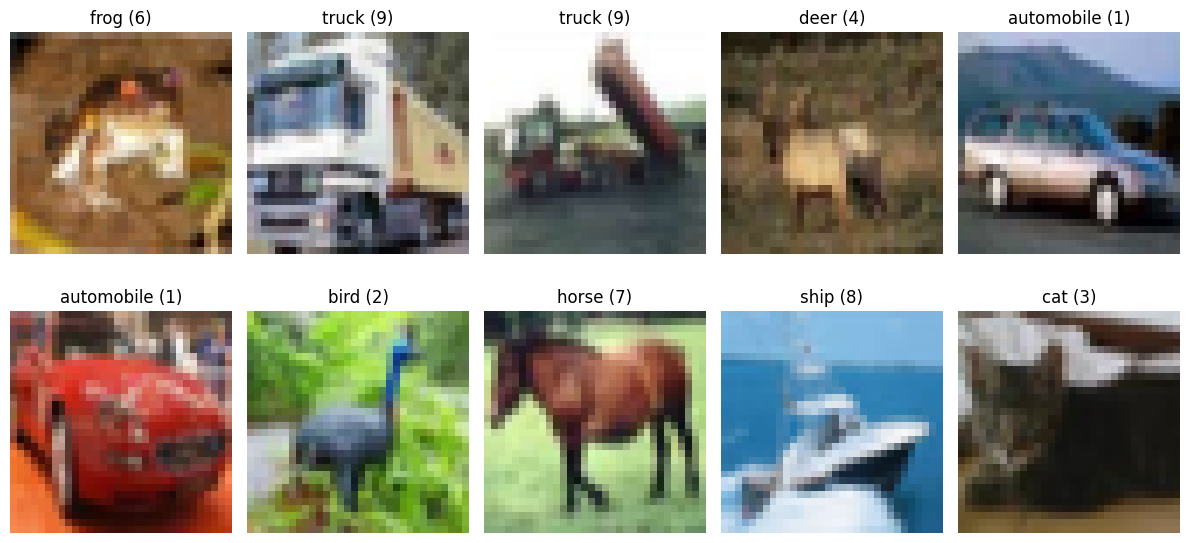

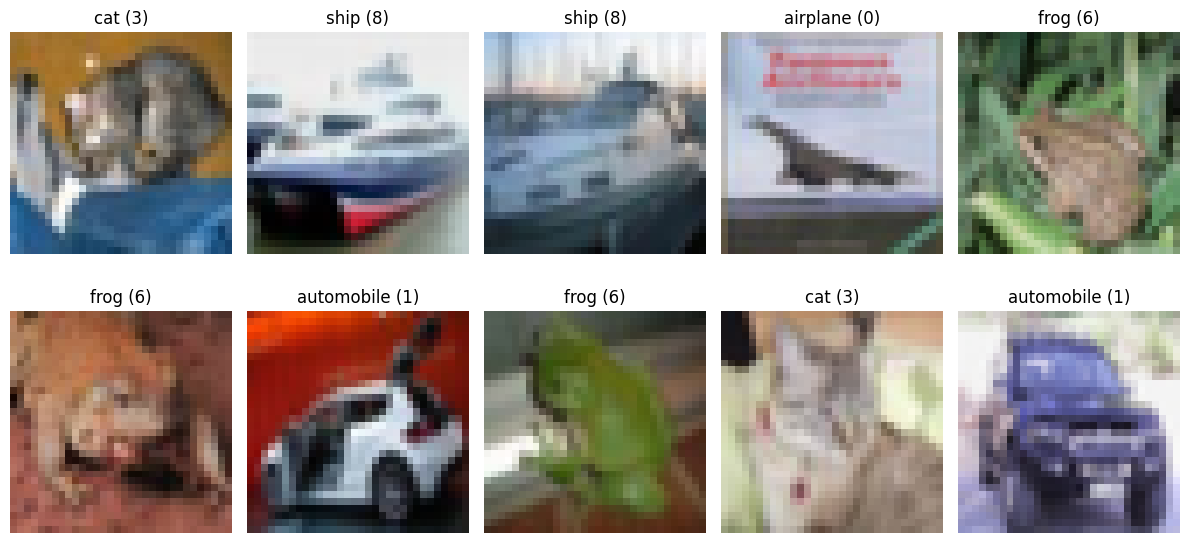

In [ ]:
# Подгрузим данные для последующего обучения

from torchvision import datasets

train_dataset = datasets.CIFAR10('./data', train=True, download=True, transform=None)
test_dataset = datasets.CIFAR10('./data', train=False, download=True, transform=None)

classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
           'dog', 'frog', 'horse', 'ship', 'truck']

def show_images(dataset, num_images=10):
    fig, axes = plt.subplots(2, 5, figsize=(12, 6))
    axes = axes.ravel()
    
    for i in range(num_images):
        image, label = dataset[i]
        
        axes[i].imshow(image)
        axes[i].set_title(f'{classes[label]} ({label})')
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()


show_images(train_dataset)

show_images(test_dataset)

In [3]:
print("Размер обучающего датасета:", len(train_dataset))
print("Размер тестового датасета:", len(test_dataset))


Размер обучающего датасета: 50000
Размер тестового датасета: 10000


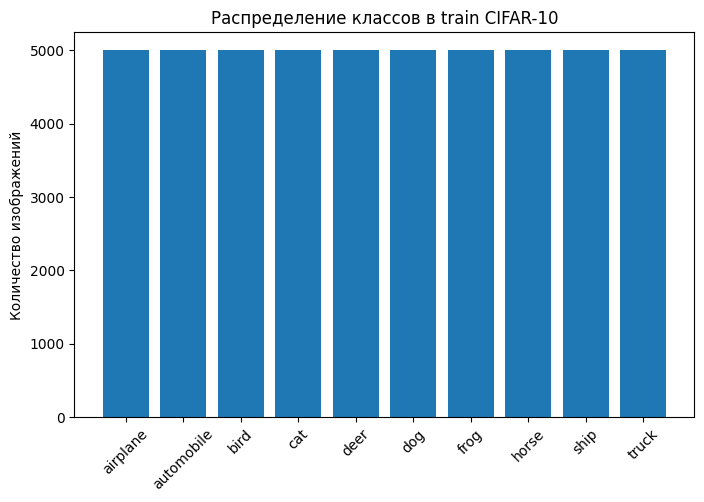

In [4]:
from collections import Counter

train_labels = [label for _, label in train_dataset]
class_counts = Counter(train_labels)

plt.figure(figsize=(8,5))
plt.bar(classes, [class_counts[i] for i in range(10)])
plt.title("Распределение классов в train CIFAR-10")
plt.xticks(rotation=45)
plt.ylabel("Количество изображений")
plt.show()


## Создание модели

In [ ]:
from torchvision import datasets
import matplotlib.pyplot as plt
import numpy as np

train_dataset = datasets.CIFAR10('./data', train=True, download=True, transform=None)

classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
           'dog', 'frog', 'horse', 'ship', 'truck']

print(len(train_dataset))
print(train_dataset[1])

image_test = train_dataset[0][0]


Files already downloaded and verified
50000
(<PIL.Image.Image image mode=RGB size=32x32 at 0x12263A8C0>, 9)
(32, 32, 3)
3072


In [ ]:
from torch import nn

from torch.optim import Adam

# Создание модели


torch.Size([1, 3072])
tensor([[0.1024, 0.0986, 0.1079, 0.0893, 0.1006, 0.1055, 0.0875, 0.1020, 0.1004,
         0.1058]], grad_fn=<SoftmaxBackward0>)


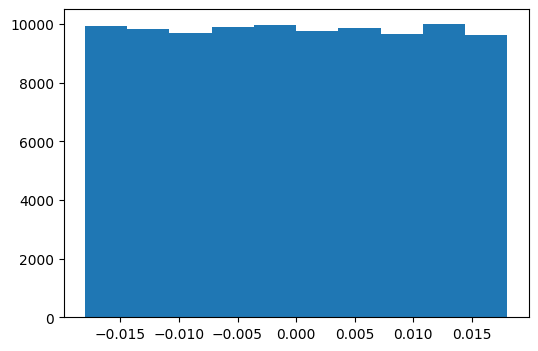

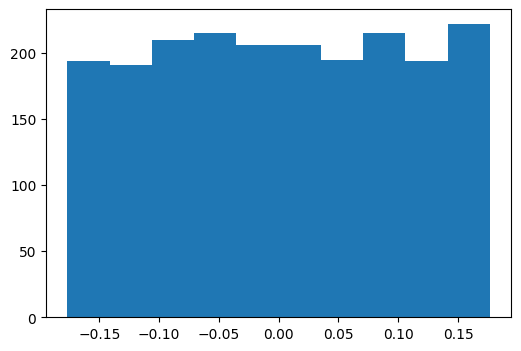

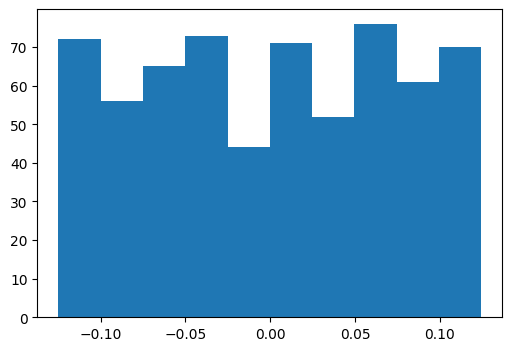

In [14]:
# можно посмотреть распределение весов по слоям

import matplotlib.pyplot as plt

for name, param in model.named_parameters():
    if "weight" in name:
        plt.figure(figsize=(6,4))
        plt.hist(param.detach().numpy().flatten())
        plt.show()


In [ ]:
# Цикл обучения

from torchvision import datasets, transforms
from tqdm import tqdm

transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10('./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False)


model = TestMLP(32*32*3, 10)

criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

epochs = 5
train_losses = []

for epoch in range(epochs):
    running_loss = 0.0
    
    for images, labels in tqdm(train_loader):
        print(labels)
        
    print(f'loss: {sum(train_losses)/ len(train_losses)}')
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {sum(train_losses)/ len(train_losses)}')


Files already downloaded and verified
Files already downloaded and verified


  0%|          | 0/782 [00:00<?, ?it/s]/Users/nikitakamenev/.pyenv/versions/3.11.10/lib/python3.11/site-packages/torch/nn/modules/module.py:1511: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
100%|██████████| 782/782 [00:07<00:00, 103.21it/s]


loss: 2.1788792610168457
Epoch [1/5], Loss: 2.1788792610168457


100%|██████████| 782/782 [00:07<00:00, 102.63it/s]


loss: 2.1540465354919434
Epoch [2/5], Loss: 2.1540465354919434


...

loss: 2.140047788619995
Epoch [3/5], Loss: 2.140047788619995


100%|██████████| 782/782 [00:07<00:00, 110.83it/s]


loss: 2.1306469440460205
Epoch [4/5], Loss: 2.1306469440460205


100%|██████████| 782/782 [00:07<00:00, 108.95it/s]


loss: 2.120579957962036
Epoch [5/5], Loss: 2.120579957962036


In [ ]:

model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        print(labels)

    print(f'Accuracy: {100 * correct / total}%')

Accuracy: 36.69%


# Инициализация весов нейросетей

При обучении нейронных сетей очень важно, **как заданы начальные значения весов**.  

Если выбрать их неправильно:
- Сеть может **не учиться** (например, если все веса одинаковые → нет различий между нейронами)  
- Обучение может быть **очень медленным** (слишком маленькие веса → сигналы затухают)  
- Может возникнуть эффект **взрыва градиентов** (слишком большие веса → активации и градиенты растут без контроля)  

---

## Основные стратегии инициализации

1. **Constant** — все веса одинаковые  
   демонстрация того, что сеть перестаёт обучаться  

2. **Низкая дисперсия** (например, `Normal(0, 0.01)`)  
   сеть учится очень медленно, сигналы почти исчезают  

3. **Высокая дисперсия** (например, `Normal(0, 1)`)  
   сеть нестабильна, градиенты взрываются  

4. **Xavier (Glorot)**  
   - подбирает дисперсию весов так, чтобы сигналы сохраняли масштаб при прохождении через слои  
   - хорошо работает для `tanh` и `sigmoid`  

5. **He (Kaiming)**  
   - модификация Xavier под `ReLU`  
   - учитывает, что часть нейронов обнуляется  
   - формула дисперсии:  



In [12]:

import torch.nn.init as init

class NetworkMLP(nn.Module):
    def __init__(self, num_inputs, num_hidden, num_outputs, act_fn=nn.Sigmoid()):
        super().__init__()
        self.linear1 = nn.Linear(num_inputs, num_hidden)
        self.act_fn = act_fn
        self.linear2 = nn.Linear(num_hidden, num_outputs)

    def forward(self, x):
        z1 = self.linear1(x)
        a1 = self.act_fn(z1)
        z2 = self.linear2(a1)
        return z1, a1, z2

In [13]:
def initialize_weights(model, mode="xavier"):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            if mode == "constant":
                init.constant_(m.weight, 0.01)
            elif mode == "low_var":
                init.normal_(m.weight, mean=0.0, std=0.01)
            elif mode == "high_var":
                init.normal_(m.weight, mean=0.0, std=1.0)
            elif mode == "xavier":
                init.xavier_uniform_(m.weight)
            elif mode == "he":
                init.kaiming_uniform_(m.weight, nonlinearity="relu")
            if m.bias is not None:
                init.constant_(m.bias, 0)


def plot_layer_distributions(model, title):
    """Распределения весов по слоям"""
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))
    layers = [model.linear1, model.linear2]

    for i, layer in enumerate(layers):
        weights = layer.weight.detach().cpu().numpy().flatten()
        axs[i].hist(weights, bins=50)
        axs[i].set_title(f"{title} | Layer {i+1}\nmean={weights.mean():.4f}, std={weights.std():.4f}")

    plt.tight_layout()
    plt.show()

def plot_activation_distributions(model, mode):
    """Распределения активаций"""
    x = torch.randn(128, 3*32*32)
    with torch.no_grad():
        z1, a1, z2 = model(x)

    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    for i, (data, name) in enumerate([(z1, "z1 pre-activation"),
                                      (a1, "a1 post-activation"),
                                      (z2, "z2 output")]):
        arr = data.cpu().numpy().flatten()
        axs[i].hist(arr, bins=50)
        axs[i].set_title(f"{mode} | {name}\nmean={arr.mean():.4f}, std={arr.std():.4f}")
    plt.tight_layout()
    plt.show()


=== CONSTANT INITIALIZATION ===


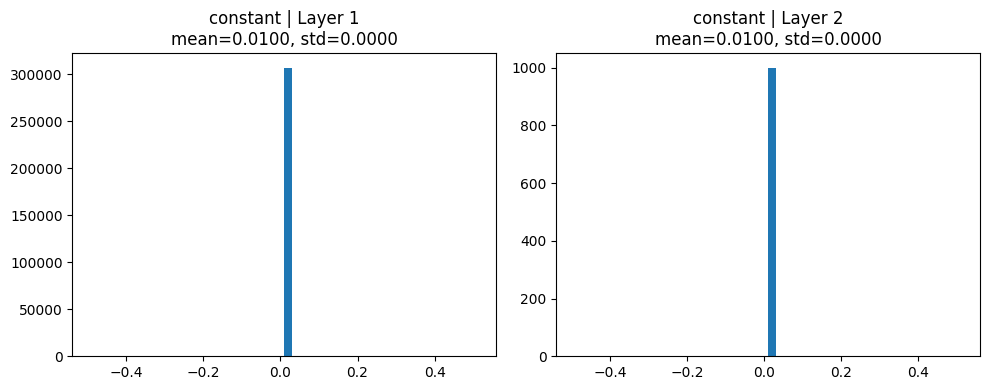

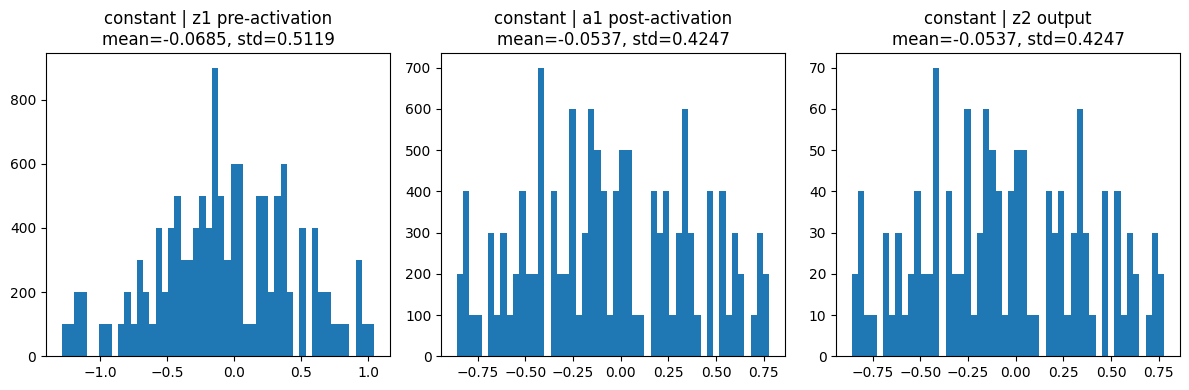


=== LOW_VAR INITIALIZATION ===


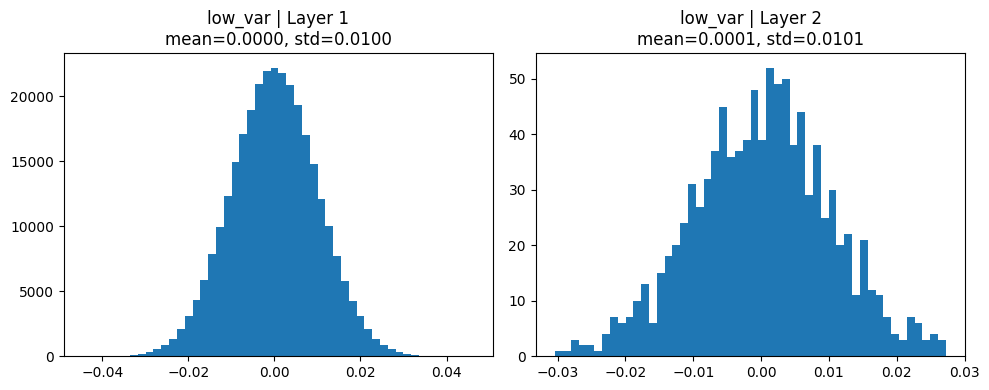

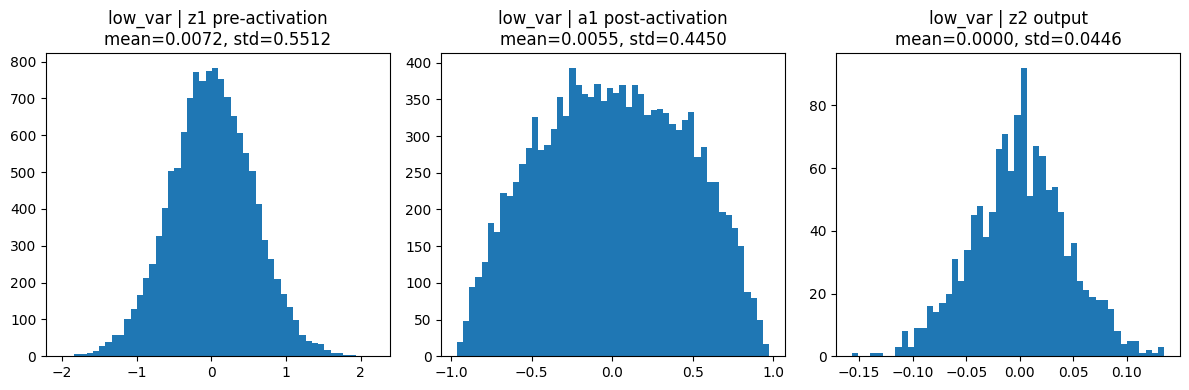


=== HIGH_VAR INITIALIZATION ===


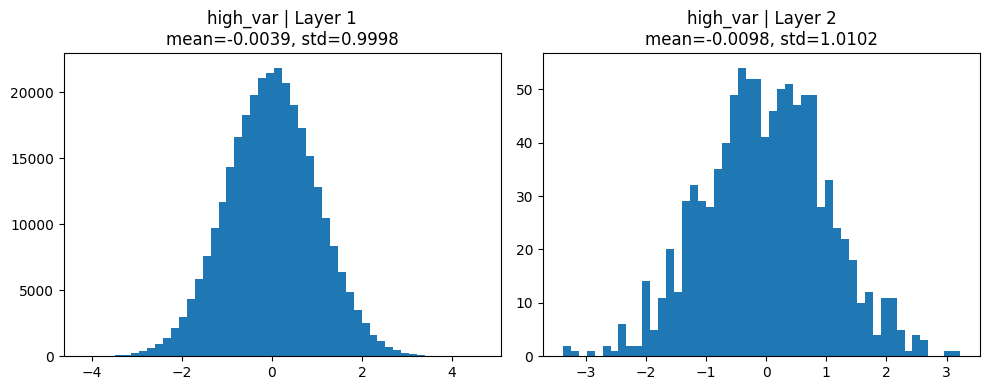

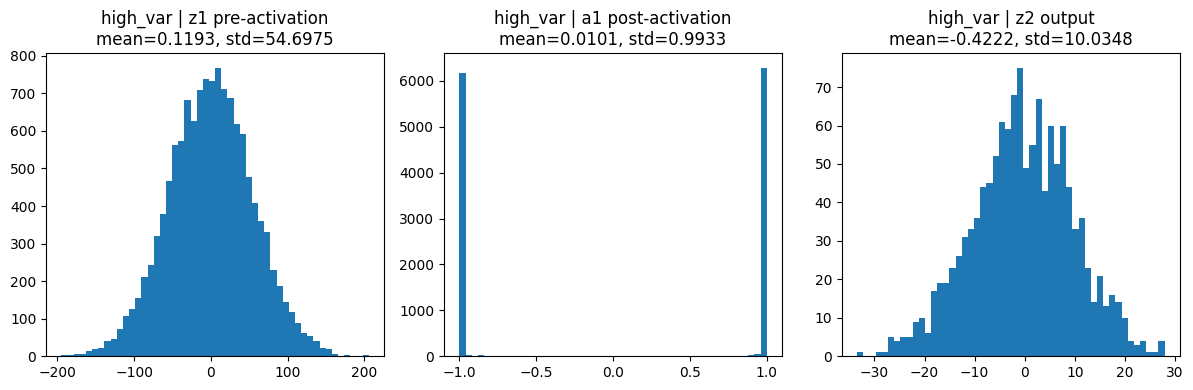


=== XAVIER INITIALIZATION ===


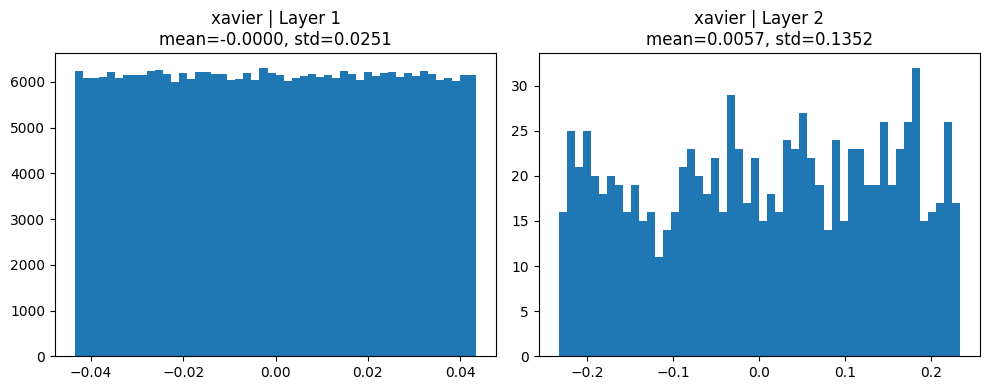

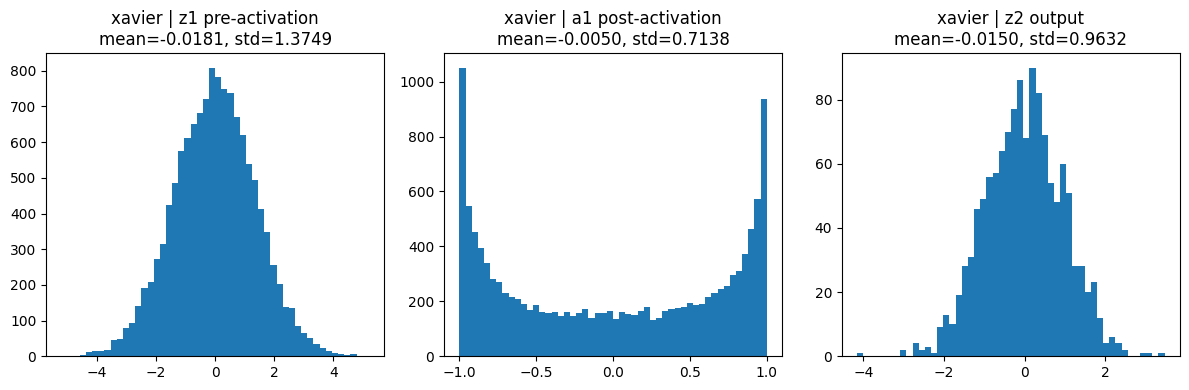


=== HE INITIALIZATION ===


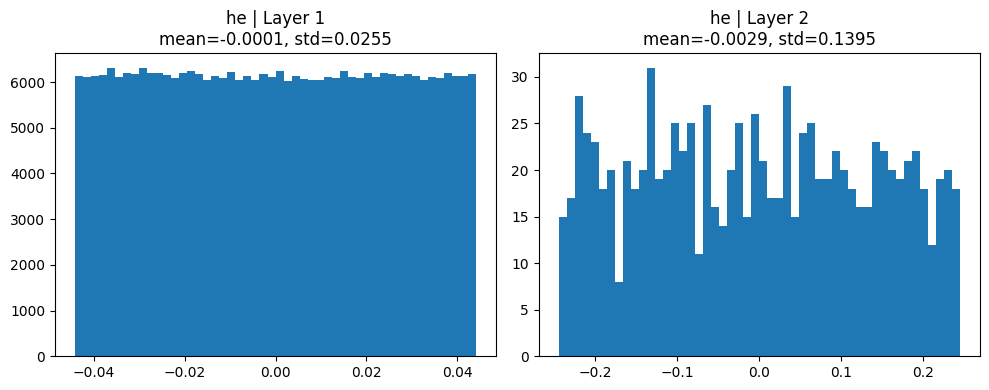

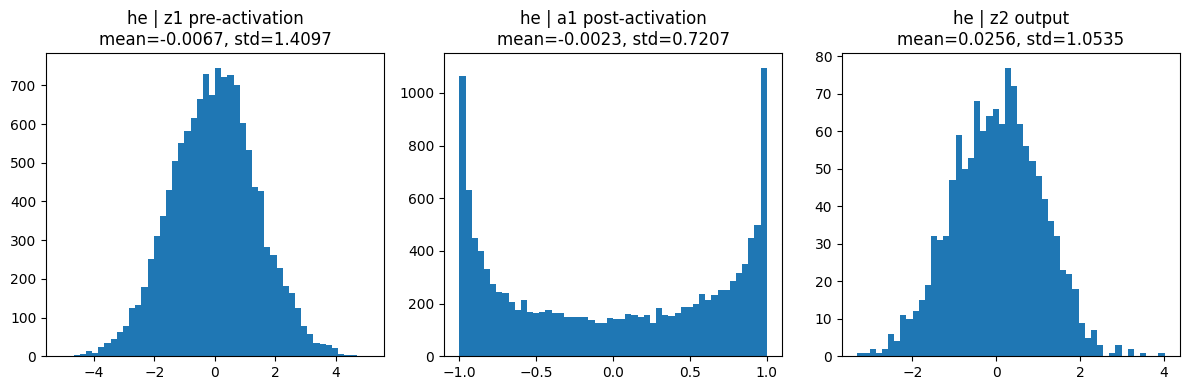

In [11]:
modes = ["constant", "low_var", "high_var", "xavier", "he"]

for mode in modes:
    print(f"\n=== {mode.upper()} INITIALIZATION ===")
    model = NetworkMLP(3*32*32, 100, 10, act_fn=nn.Tanh())
    initialize_weights(model, mode=mode)

    # Веса по слоям
    plot_layer_distributions(model, mode)

    # Активации
    plot_activation_distributions(model, mode)

# Сверточная нейронная сеть


In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
           'dog', 'frog', 'horse', 'ship', 'truck']

Files already downloaded and verified
Files already downloaded and verified


In [ ]:
import torch.nn.functional as F


class ConvNet(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return x
    
model = ConvNet()

tensor([[-0.1317, -0.0564, -0.0720, -0.1465,  0.1737,  0.1476,  0.1527,  0.1749,
         -0.1423,  0.1070]], grad_fn=<AddmmBackward0>)

In [ ]:
# Цикл обучения
from torchvision import datasets, transforms
from tqdm import tqdm

transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10('./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
# test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False)


model = ConvNet()

criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

epochs = 5
train_losses = []

for epoch in range(epochs):
    running_loss = 0.0
    
    for images, labels in tqdm(train_loader):
        # считаем лосс и обновляем градиенты

        print(f'loss: {sum(train_losses)/ len(train_losses)}')

    print(f'Epoch [{epoch+1}/{epochs}], Loss: {sum(train_losses)/ len(train_losses)}')


Files already downloaded and verified
Files already downloaded and verified


100%|██████████| 782/782 [00:28<00:00, 27.62it/s]


loss: 1.4936941862106323
Epoch [1/5], Loss: 1.4936941862106323


100%|██████████| 782/782 [00:32<00:00, 24.24it/s]


loss: 1.305738091468811
Epoch [2/5], Loss: 1.305738091468811


...

loss: 1.1937717199325562
Epoch [3/5], Loss: 1.1937717199325562


100%|██████████| 782/782 [00:30<00:00, 25.35it/s]


loss: 1.112277626991272
Epoch [4/5], Loss: 1.112277626991272


100%|██████████| 782/782 [00:32<00:00, 23.95it/s]


loss: 1.048629641532898
Epoch [5/5], Loss: 1.048629641532898


In [24]:

model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f'Accuracy: {100 * correct / total}%')

Accuracy: 46.29%


В PyTorch **нет отдельной функции** с названием `global_avg_pool2d`.  

Вместо этого используют **адаптивное усреднение**, которое позволяет задать любой размер выходного тензора:  

- Функция: `torch.nn.functional.adaptive_avg_pool2d`  
- Слой: `nn.AdaptiveAvgPool2d`  

Если задать `output_size=1`, то результат соответствует **Global Average Pooling** по всем пространственным координатам.


In [ ]:
# Модель с global avg pooling

import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvNetGAP(nn.Module):
    def __init__(self):
        super().__init__()


    def forward(self, x):

        return x

model = ConvNetGAP()



Выход модели: torch.Size([1, 10])
